# Практическое занятие: базовые методы анализа сетевого трафика

---
## Структура ноутбука

1. **Блок 1. pcap → DataFrame.** Потоковое чтение, таблица пакетов, таблица потоков (5-tuple).
2. **Блок 2. Описательная статистика.** Распределения, CDF, QQ, тесты нормальности.
3. **Блок 3. Анализ сеансов.** Классификация TCP-потоков, сбойные диалоги.
4. **Блок 4. Fumbling.** Сканирование (по горизонтали и вертикали), ICMP-ошибки, DNS/HTTP-fumbling.
5. **Блок 5. Объём, время, биконинг.** Рабочий профиль, автокорреляция межинтервалов, локальность.
6. **Блок 6. Контент и граф связей.** DNS, HTTP, TLS SNI; идентификация приложений; NetworkX.

## 0. Подготовка окружения

Устанавливаем недостающие пакеты (если запуск ведётся впервые) и
фиксируем общие настройки отображения.

In [1]:
# При первом запуске раскомментируйте:
# !pip install scapy pandas numpy matplotlib seaborn scipy networkx --quiet

import warnings, os, math, itertools, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import networkx as nx
from scapy.all import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titleweight"] = "bold"
np.random.seed(42)

PCAP_PATH = Path("4SICS-GeekLounge-151020.pcap")
assert PCAP_PATH.exists(), f"pcap не найден: {PCAP_PATH}"
print("Файл готов:", PCAP_PATH, f"{PCAP_PATH.stat().st_size/1e6:.1f} МБ")


Файл готов: 4SICS-GeekLounge-151020.pcap 25.7 МБ


---
# Блок 1. pcap → DataFrame: подготовка данных

> **Collins, гл. 1, 3.** «Quality source data is integral to good security analysis».
> Сетевой трафик - это компромисс выразительности и объёма:
> pcap содержит всё, но поиск по нему дорог.

## Что здесь делаем

1. **Потоковое чтение.** `scapy.PcapReader` разбирает пакеты по одному и не грузит дамп целиком в память. Для учебного дампа ~25 МБ это избыточно, но привычка полезная: на реальной «боевой» задаче дампы измеряются гигабайтами.
2. **Таблица пакетов.** Один пакет - одна строка. Табличное представление позволяет извлечь наиболее важную информацию из пакетов и далее обрабатывать их, используя все возможности pandas
3. **Таблица потоков.** Агрегация по 5-tuple (src, sport, dst, dport, proto).



In [2]:
%%time


def parse_pcap(path, limit=None):
    rows = []
    with PcapReader(str(path)) as rdr:
        for i, pkt in enumerate(rdr):
            if limit and i >= limit:
                break
            row = {
                "ts": float(pkt.time),
                "length": len(pkt),
                "src_mac": pkt[Ether].src if pkt.haslayer(Ether) else None,
                "dst_mac": pkt[Ether].dst if pkt.haslayer(Ether) else None,
                "src_ip": None, "dst_ip": None,
                "ip_ver": None, "l4": None,
                "src_port": None, "dst_port": None,
                "tcp_flags": None, "icmp_type": None, "icmp_code": None,
            }
            if pkt.haslayer(IP):
                ip = pkt[IP];   row.update(src_ip=ip.src, dst_ip=ip.dst, ip_ver=4)
            elif pkt.haslayer(IPv6):
                ip = pkt[IPv6]; row.update(src_ip=ip.src, dst_ip=ip.dst, ip_ver=6)
            if pkt.haslayer(TCP):
                t = pkt[TCP]
                row.update(l4="TCP", src_port=int(t.sport), dst_port=int(t.dport),
                           tcp_flags=str(t.flags))
            elif pkt.haslayer(UDP):
                u = pkt[UDP]
                row.update(l4="UDP", src_port=int(u.sport), dst_port=int(u.dport))
            elif pkt.haslayer(ICMP):
                ic = pkt[ICMP]
                row.update(l4="ICMP", icmp_type=int(ic.type), icmp_code=int(ic.code))
            rows.append(row)
    df = pd.DataFrame(rows)
    df["dt"] = pd.to_datetime(df["ts"], unit="s", utc=True)
    return df

pkts = parse_pcap(PCAP_PATH, limit=None)
print(f"Прочитано пакетов: {len(pkts)}")

Прочитано пакетов: 246137
CPU times: total: 45.4 s
Wall time: 45.9 s


In [3]:
pkts.head()

,ts,length,src_mac,dst_mac,src_ip,dst_ip,ip_ver,l4,src_port,dst_port,tcp_flags,icmp_type,icmp_code,dt
0,1.445354e+09,73,00:90:e8:27:8c:37,00:07:7c:1a:61:83,192.168.88.61,192.168.88.1,4.0,UDP,949.0,53.0,NaN,NaN,NaN,2015-10-20 15:10:34.524709940+00:00
1,1.445354e+09,73,00:07:7c:1a:61:83,00:90:e8:27:8c:37,192.168.88.1,192.168.88.61,4.0,UDP,53.0,949.0,NaN,NaN,NaN,2015-10-20 15:10:34.525737047+00:00
2,1.445354e+09,73,00:90:e8:27:8c:37,00:07:7c:1a:61:83,192.168.88.61,192.168.88.1,4.0,UDP,949.0,53.0,NaN,NaN,NaN,2015-10-20 15:10:36.525645971+00:00
3,1.445354e+09,73,00:07:7c:1a:61:83,00:90:e8:27:8c:37,192.168.88.1,192.168.88.61,4.0,UDP,53.0,949.0,NaN,NaN,NaN,2015-10-20 15:10:36.526669979+00:00
4,1.445354e+09,73,00:90:e8:27:8c:37,00:07:7c:1a:61:83,192.168.88.61,192.168.88.1,4.0,UDP,949.0,53.0,NaN,NaN,NaN,2015-10-20 15:10:38.527005911+00:00


### Таблица потоков по 5-tuple

Поток это совокупность пакетов с одинаковыми 5-tuple (имеет смысл только для l4 трафика TCP или UDP).

In [4]:
#определяем 5-tuple на основе адресов из пакета:
#для каноничности всегда упорядочиваем лексикографически адреса (IP и порт)
#если при упорядочивании не было перестановки - это прямое направление пакета
#если была перестановка - это обратное направление 
#ВАЖНО: такое определение направления не может гарантированно определить роли клиента и сервера!
#однако эвристика, что номер порта сервера всегда меньше номера порта клиента работает в большинстве случаев
def canon_key(s):
    # Канонизируем 5-tuple: лексикографически меньшая сторона идёт первой (номер порта сравнивается до IP адреса). 
    a = (int(s['src_port']) if s['src_port'] is not None else -1, str(s['src_ip']))
    b = (int(s['dst_port']) if s['dst_port'] is not None else -1, str(s['dst_ip']))
    if a > b:
        s['flow_key'] = (a[1], a[0], b[1], b[0], s['l4'])
        s['direction'] = "forward"
        return s
    else:
        s['flow_key'] = (b[1], b[0], a[1], a[0], s['l4'])
        s['direction'] = "reverse"  
        return s

In [5]:
#выделяем только интересующие протоколы (TCP, UDP, ICMP)
mask = pkts["src_ip"].notna() & pkts["dst_ip"].notna() & pkts["l4"].isin(["TCP","UDP","ICMP"])
p = pkts[mask].copy()

In [6]:
#причесываем DataFrame
p["src_port"] = p["src_port"].fillna(-1).astype(int)
p["dst_port"] = p["dst_port"].fillna(-1).astype(int)
p["flow_key"] = None
p["direction"] = None

In [7]:
%%time
p = p.apply(canon_key, axis=1)

CPU times: total: 18.2 s
Wall time: 18.3 s


In [8]:
%%time
flows = p.groupby("flow_key").agg(
        start = ("ts", "min"),
        end   = ("ts", "max"),
        pkts  = ("ts", "size"),
        bytes_total = ("length", "sum"),
        pkts_fwd = ("direction", lambda x: (x=="forward").sum()),
        pkts_rev = ("direction", lambda x: (x=="reverse").sum()),
        bytes_fwd = ("length",   lambda x: x[p.loc[x.index,"direction"]=="forward"].sum()),
        bytes_rev = ("length",   lambda x: x[p.loc[x.index,"direction"]=="reverse"].sum()),
        tcp_flags_set = ("tcp_flags", lambda x: set([f for f in x.dropna()])),
    ).reset_index()

CPU times: total: 7.91 s
Wall time: 7.98 s


In [9]:
flows

,flow_key,start,end,pkts,bytes_total,pkts_fwd,pkts_rev,bytes_fwd,bytes_rev,tcp_flags_set
0,"(10.10.10.20, 49156, 10.10.10.10, 102, TCP)",1.445355e+09,1.445379e+09,146329,15276785,94859,51470,10102033,5174752,"{A, PA}"
1,"(10.10.10.30, 49909, 10.10.10.10, 102, TCP)",1.445355e+09,1.445363e+09,524,32340,269,255,16752,15588,"{A, RA, PA}"
2,"(10.10.10.30, 50531, 10.10.10.10, 102, TCP)",1.445355e+09,1.445355e+09,2,120,1,1,60,60,{A}
3,"(10.10.10.30, 50532, 10.10.10.10, 102, TCP)",1.445355e+09,1.445355e+09,2,120,1,1,60,60,{A}
4,"(10.10.10.30, 50560, 10.10.10.10, 102, TCP)",1.445355e+09,1.445355e+09,2,120,1,1,60,60,{A}
...,...,...,...,...,...,...,...,...,...,...
9814,"(192.168.89.2, 65343, 8.8.8.8, 53, UDP)",1.445364e+09,1.445364e+09,1,69,1,0,69,0,{}
9815,"(192.168.89.2, 65370, 8.8.8.8, 53, UDP)",1.445364e+09,1.445364e+09,1,69,1,0,69,0,{}
9816,"(192.168.89.2, 65373, 8.8.8.8, 53, UDP)",1.445378e+09,1.445378e+09,1,69,1,0,69,0,{}
9817,"(192.168.89.2, 65378, 8.8.8.8, 53, UDP)",1.445374e+09,1.445374e+09,1,69,1,0,69,0,{}


In [10]:
flows[["src_ip","src_port","dst_ip","dst_port","l4"]] = pd.DataFrame(
        flows["flow_key"].tolist(), index=flows.index
    )
flows["duration"] = flows["end"] - flows["start"]

In [11]:
flows.sort_values("pkts", ascending=False).head(5)

,flow_key,start,end,pkts,bytes_total,pkts_fwd,pkts_rev,bytes_fwd,bytes_rev,tcp_flags_set,src_ip,src_port,dst_ip,dst_port,l4,duration
0,"(10.10.10.20, 49156, 10.10.10.10, 102, TCP)",1.445355e+09,1.445379e+09,146329,15276785,94859,51470,10102033,5174752,"{A, PA}",10.10.10.20,49156,10.10.10.10,102,TCP,24299.766620
7371,"(192.168.88.61, 949, 192.168.88.1, 53, UDP)",1.445354e+09,1.445379e+09,24661,1800253,12331,12330,900163,900090,{},192.168.88.61,949,192.168.88.1,53,UDP,25197.673050
7372,"(192.168.89.2, -1, 192.168.89.1, -1, ICMP)",1.445354e+09,1.445379e+09,2735,266609,0,2735,0,266609,{},192.168.89.2,-1,192.168.89.1,-1,ICMP,25185.334305
1,"(10.10.10.30, 49909, 10.10.10.10, 102, TCP)",1.445355e+09,1.445363e+09,524,32340,269,255,16752,15588,"{A, RA, PA}",10.10.10.30,49909,10.10.10.10,102,TCP,7253.567572
7408,"(192.168.89.2, 2056, 8.8.8.8, 53, UDP)",1.445354e+09,1.445367e+09,126,9324,126,0,9324,0,{},192.168.89.2,2056,8.8.8.8,53,UDP,12908.433036


In [12]:
#сколько потоков состоят всего из одного пакета
(flows["pkts"] == 1).sum()

np.int64(2402)

In [13]:
#распределение потоков по протоколам (по количеству и переданным байтам)
by_l4_flows = flows["l4"].value_counts(normalize=True).rename("share_flows")
by_l4_bytes = flows.groupby("l4")["bytes_total"].sum()
by_l4_bytes = (by_l4_bytes / by_l4_bytes.sum()).rename("share_bytes")
pd.concat([by_l4_flows, by_l4_bytes], axis=1)

,share_flows,share_bytes
l4,,
TCP,0.742642,0.893541
UDP,0.257154,0.093945
ICMP,0.000204,0.012514


### Исследование конечных узлов дампа и предположений о топологии сети

In [14]:
pkts

,ts,length,src_mac,dst_mac,src_ip,dst_ip,ip_ver,l4,src_port,dst_port,tcp_flags,icmp_type,icmp_code,dt
0,1.445354e+09,73,00:90:e8:27:8c:37,00:07:7c:1a:61:83,192.168.88.61,192.168.88.1,4.0,UDP,949.0,53.0,NaN,NaN,NaN,2015-10-20 15:10:34.524709940+00:00
1,1.445354e+09,73,00:07:7c:1a:61:83,00:90:e8:27:8c:37,192.168.88.1,192.168.88.61,4.0,UDP,53.0,949.0,NaN,NaN,NaN,2015-10-20 15:10:34.525737047+00:00
2,1.445354e+09,73,00:90:e8:27:8c:37,00:07:7c:1a:61:83,192.168.88.61,192.168.88.1,4.0,UDP,949.0,53.0,NaN,NaN,NaN,2015-10-20 15:10:36.525645971+00:00
3,1.445354e+09,73,00:07:7c:1a:61:83,00:90:e8:27:8c:37,192.168.88.1,192.168.88.61,4.0,UDP,53.0,949.0,NaN,NaN,NaN,2015-10-20 15:10:36.526669979+00:00
4,1.445354e+09,73,00:90:e8:27:8c:37,00:07:7c:1a:61:83,192.168.88.61,192.168.88.1,4.0,UDP,949.0,53.0,NaN,NaN,NaN,2015-10-20 15:10:38.527005911+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246132,1.445379e+09,104,28:63:36:89:59:82,00:1c:06:27:64:11,10.10.10.10,10.10.10.20,4.0,TCP,102.0,49156.0,PA,NaN,NaN,2015-10-20 22:10:31.346725941+00:00
246133,1.445379e+09,104,28:63:36:89:59:82,00:1c:06:27:64:11,10.10.10.10,10.10.10.20,4.0,TCP,102.0,49156.0,PA,NaN,NaN,2015-10-20 22:10:31.346725941+00:00
246134,1.445379e+09,60,00:1c:06:27:64:11,28:63:36:89:59:82,10.10.10.20,10.10.10.10,4.0,TCP,49156.0,102.0,A,NaN,NaN,2015-10-20 22:10:31.396080017+00:00
246135,1.445379e+09,60,00:1c:06:27:64:11,28:63:36:89:59:82,10.10.10.20,10.10.10.10,4.0,TCP,49156.0,102.0,A,NaN,NaN,2015-10-20 22:10:31.396080017+00:00


In [15]:
melted_pkts = pkts[['src_ip','dst_ip']].melt()

In [17]:
melted_pkts

,variable,value
0,src_ip,192.168.88.61
1,src_ip,192.168.88.1
2,src_ip,192.168.88.61
3,src_ip,192.168.88.1
4,src_ip,192.168.88.61
...,...,...
492269,dst_ip,10.10.10.20
492270,dst_ip,10.10.10.20
492271,dst_ip,10.10.10.10
492272,dst_ip,10.10.10.10


In [16]:
#определим количество уникальных IP и MAC адресов
melted_pkts['value'].unique()

<StringArray>
[ '192.168.88.61',   '192.168.88.1',   '192.168.89.2',   '192.168.89.1',              nan,    '10.10.10.20',    '10.10.10.10',
    '10.10.10.30',  '192.168.88.52',       '21.2.2.2',        '8.8.8.8',  '17.253.34.253', '192.195.142.13']
Length: 13, dtype: str

In [18]:
#выборка всех l3 пакетов (у которых есть IP адрес)
pkts_l3 = pkts[pkts['src_ip'].notna()]

In [19]:
#создание единого датафрейма со всеми парами IP - MAC (для источника и назначения)
ip_mac = pd.DataFrame(np.vstack((pkts_l3[['src_ip', 'src_mac']].to_numpy(),pkts_l3[['dst_ip', 'dst_mac']].to_numpy())),columns=['IP','MAC'])


In [20]:
ip_mac

,IP,MAC
0,192.168.88.61,00:90:e8:27:8c:37
1,192.168.88.1,00:07:7c:1a:61:83
2,192.168.88.61,00:90:e8:27:8c:37
3,192.168.88.1,00:07:7c:1a:61:83
4,192.168.88.61,00:90:e8:27:8c:37
...,...,...
478529,10.10.10.20,00:1c:06:27:64:11
478530,10.10.10.20,00:1c:06:27:64:11
478531,10.10.10.10,28:63:36:89:59:82
478532,10.10.10.10,28:63:36:89:59:82


In [21]:
#переводим в граф - вершины это адреса, а ребра там, где есть соответствие IP - MAC
G = nx.from_pandas_edgelist(ip_mac, source='IP', target='MAC')

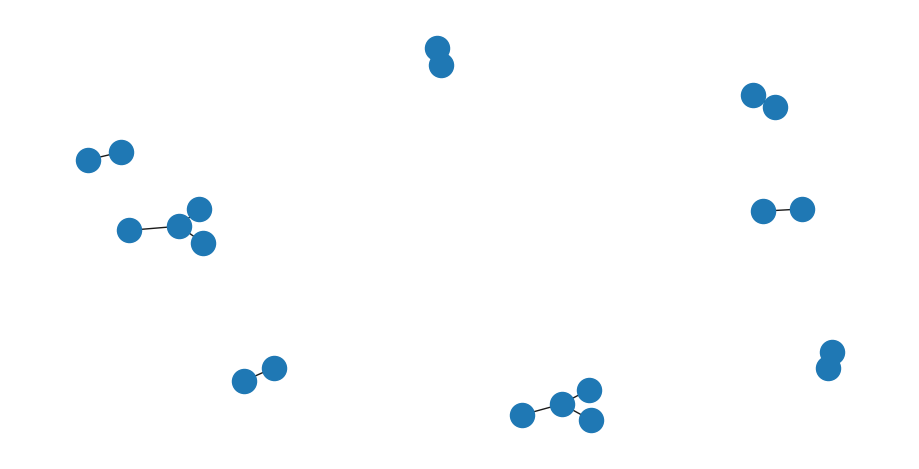

In [22]:
nx.draw(G)

In [23]:
#предположительно маршрутизаторы - это те MAC адреса, которым соответствует более одного IP адреса
routers = [n for n in G.nodes() if G.degree(n) > 1]

In [24]:
routers

['00:07:7c:1a:61:83', '00:0a:dc:64:85:c2']

In [25]:
#вывод смежных вершин для первого маршрутизатора
list(G.neighbors(routers[0]))

['192.168.88.1', '21.2.2.2', '192.195.142.13']

In [26]:
#вывод смежных вершин для второго маршрутизатора
list(G.neighbors(routers[1]))

['192.168.89.1', '8.8.8.8', '17.253.34.253']

---
# Блок 2. Описательная статистика и распределения


In [27]:
length = pkts["length"]
iat_all = pkts["ts"].diff().dropna()
iat_all = iat_all[iat_all > 0]  # отбросим нулевые — одновременные пакеты

summary = pd.DataFrame({
    "packet_length": length.describe(),
    "interarrival_sec": iat_all.describe(),
})
summary


,packet_length,interarrival_sec
count,246137.000000,1.605070e+05
mean,88.458322,1.569880e-01
std,35.572350,6.607469e-01
min,60.000000,9.536743e-07
25%,60.000000,1.120090e-03
50%,73.000000,1.629806e-02
75%,104.000000,1.747510e-01
max,153.000000,2.345773e+02


## Анализ длин пакетов
Для анализа метаданных пакетов используются два основных представления: гистограмма и график ECDF (Empirical Cumulative Distribution Function) - эмпирическая накопленная функция распределения
Гистограммы (столбчатые диаграммы распределения) очень зависят от того, на сколько бинов вы разделили данные.
Если бинов слишком мало — теряются детали.
Если слишком много — появляется шум.
ECDF не имеет параметров, она показывает все данные как есть, без агрегации.

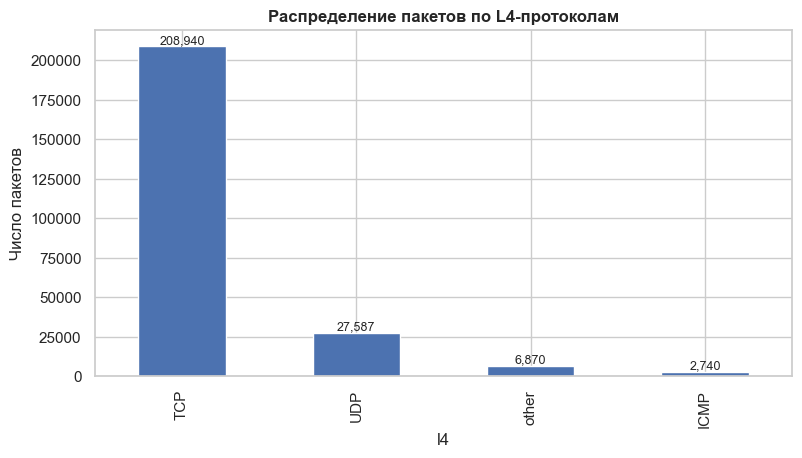

In [28]:
# Bar chart распределения по протоколам
proto_counts = pkts["l4"].fillna("other").value_counts()
ax = proto_counts.plot.bar(color="#4C72B0")
ax.set_title("Распределение пакетов по L4-протоколам")
ax.set_ylabel("Число пакетов")
for i, v in enumerate(proto_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.show()


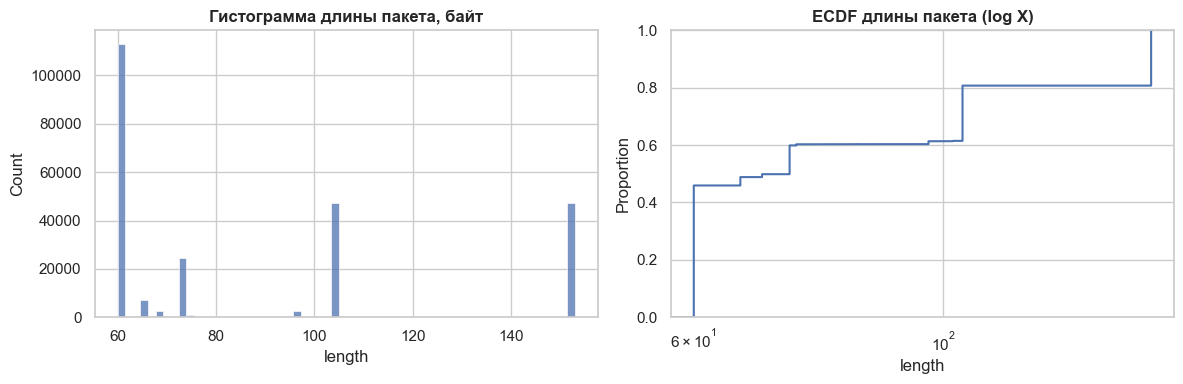

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(length, bins=60, ax=axes[0], kde=False)
axes[0].set_title("Гистограмма длины пакета, байт")
sns.ecdfplot(length, ax=axes[1])
axes[1].set_xscale("log"); axes[1].set_title("ECDF длины пакета (log X)")
plt.tight_layout(); plt.show()


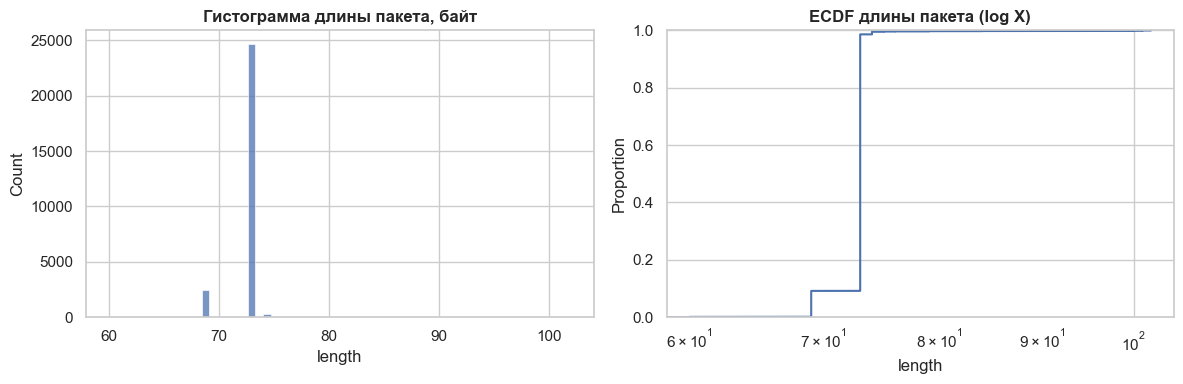

In [187]:
length = pkts[pkts['l4'] == 'UDP']['length']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(length, bins=60, ax=axes[0], kde=False)
axes[0].set_title("Гистограмма длины пакета, байт")
sns.ecdfplot(length, ax=axes[1])
axes[1].set_xscale("log"); axes[1].set_title("ECDF длины пакета (log X)")
plt.tight_layout(); plt.show()

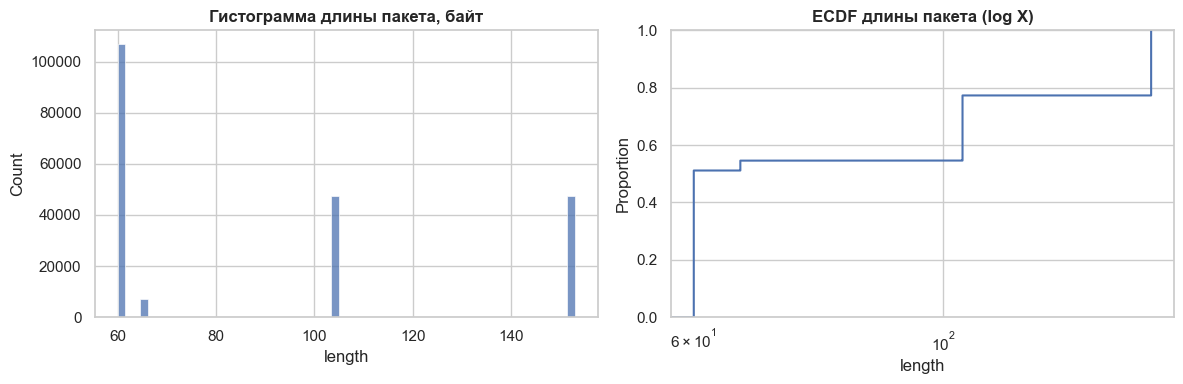

In [31]:
length = pkts[pkts['l4'] == 'TCP']['length']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(length, bins=60, ax=axes[0], kde=False)
axes[0].set_title("Гистограмма длины пакета, байт")
sns.ecdfplot(length, ax=axes[1])
axes[1].set_xscale("log"); axes[1].set_title("ECDF длины пакета (log X)")
plt.tight_layout(); plt.show()

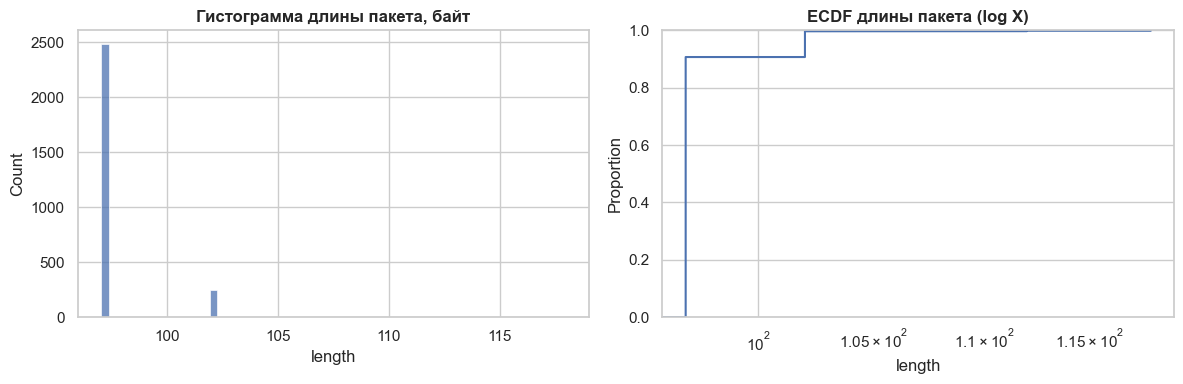

In [189]:
length = pkts[pkts['l4'] == 'ICMP']['length']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(length, bins=60, ax=axes[0], kde=False)
axes[0].set_title("Гистограмма длины пакета, байт")
sns.ecdfplot(length, ax=axes[1])
axes[1].set_xscale("log"); axes[1].set_title("ECDF длины пакета (log X)")
plt.tight_layout(); plt.show()

## Анализ межпакетных интервалов

При анализе межпакетных интервалов возникает проблема "длинного хвоста", значения, которые наблюдаются чаще всего "ломают" масштаб и делают невозможным анализ более редких значений. По этой причине традиционно применяется двойная логарифмическая шкала

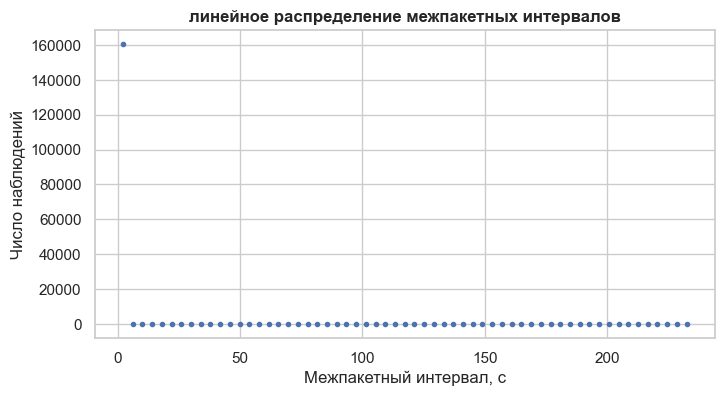

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
hist, edges = np.histogram(iat_all, bins=np.linspace(iat_all.min(),
                                                     iat_all.max(), 60))
centers = (edges[:-1]+edges[1:]) / 2
ax.scatter(centers, hist , marker=".", linestyle="None")
ax.set_xlabel("Межпакетный интервал, с")
ax.set_ylabel("Число наблюдений")
ax.set_title("линейное распределение межпакетных интервалов")
plt.show()

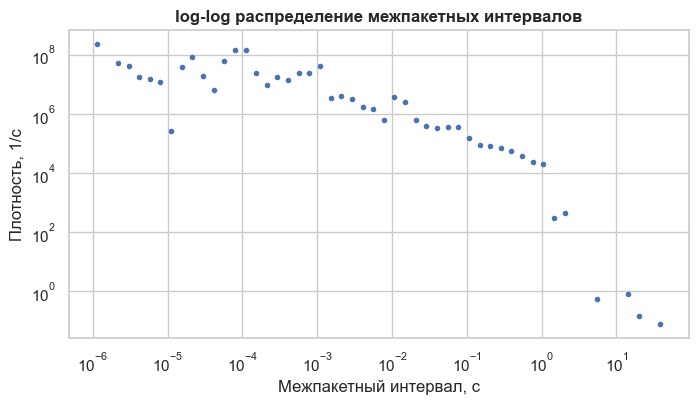

In [36]:
# log-log гистограмма межпакетного интервала — тяжёлые хвосты видны визуально
fig, ax = plt.subplots(figsize=(8, 4))

iat_pos = iat_all[iat_all > 0]
edges = np.logspace(np.log10(iat_pos.min()),
                    np.log10(iat_pos.max()), 60)
hist, _ = np.histogram(iat_pos, bins=edges)
widths = np.diff(edges)
centers = np.sqrt(edges[:-1] * edges[1:])
density = hist / widths

mask = hist > 0
ax.loglog(centers[mask], density[mask], marker=".", linestyle="None")

ax.set_xlabel("Межпакетный интервал, с")
ax.set_ylabel("Плотность, 1/с")
ax.set_title("log-log распределение межпакетных интервалов")
#ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()


---
# Блок 3. Анализ сеансов

> Состояние TCP-потока
> определяется наблюдаемой последовательностью флагов. Нас интересуют пять
> классов:
>
> - **full** — наблюдалось полное "тройное рукопожатие" (SYN, SYN+ACK, ACK);
> - **syn_only** — только SYN от инициатора, ответа нет;
> - **syn_synack_no_ack** — есть SYN-ACK, но инициатор не завершил рукопожатие;
> - **rst_terminated** — встречался RST;
> - **fin_closed** — корректное завершение с FIN;
> - **unknown/other** — остальные комбинации.

## Почему это важно

SYN без ответа и масса half-open соединений — классический признак сканирования (или примитивной DDoS атаки).

In [38]:
def classify_tcp(flag_set):
    s = set(flag_set) if flag_set else set()
    has_syn     = any("S" in f and "A" not in f for f in s)   # S без A
    has_synack  = any("S" in f and "A" in f for f in s)       # SA
    has_ack_only= any(f == "A" for f in s)
    has_rst     = any("R" in f for f in s)
    has_fin     = any("F" in f for f in s)
    if has_rst:                                   return "rst_terminated"
    if has_syn and has_synack and has_ack_only:   return "full"
    if has_syn and has_synack and not has_ack_only: return "syn_synack_no_ack"
    if has_syn and not has_synack:                return "syn_only"
    if has_fin and has_synack:                    return "fin_closed"
    return "other"

class
rst_terminated    7223
full                63
other                6
Name: count, dtype: int64


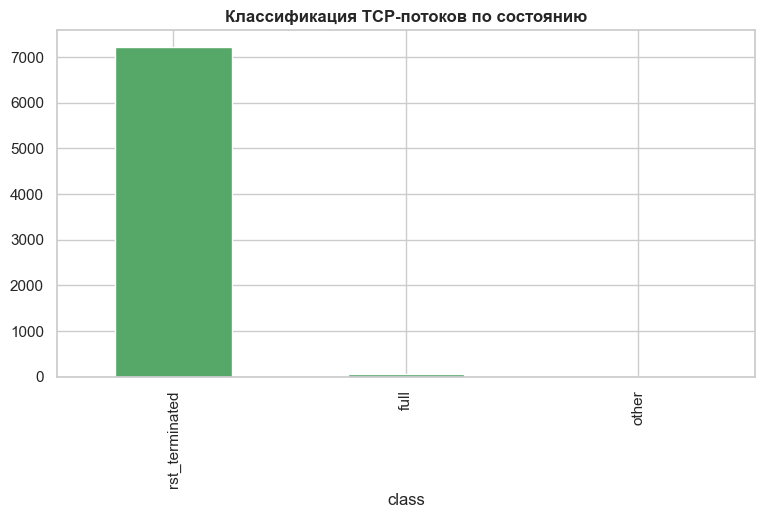

In [39]:
tcp = flows[flows["l4"] == "TCP"].copy()
tcp["class"] = tcp["tcp_flags_set"].apply(classify_tcp)
tcp_class_counts = tcp["class"].value_counts()
print(tcp_class_counts)
ax = tcp_class_counts.plot.bar(color="#55A868")
ax.set_title("Классификация TCP-потоков по состоянию")
plt.show()


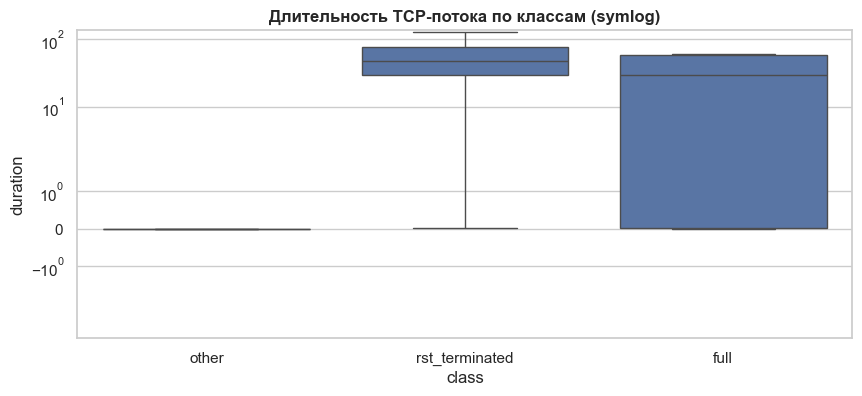


10 самых длинных TCP-сессий:


,src_ip,src_port,dst_ip,dst_port,pkts,bytes_total,duration,class
0,10.10.10.20,49156,10.10.10.10,102,146329,15276785,24299.766620,other
1,10.10.10.30,49909,10.10.10.10,102,524,32340,7253.567572,rst_terminated
1829,10.10.10.30,52872,10.10.10.10,102,88,5286,1271.309336,rst_terminated
2561,10.10.10.30,53604,10.10.10.10,102,17,1026,130.743199,rst_terminated
2562,10.10.10.30,53605,10.10.10.10,102,17,1026,129.854820,rst_terminated
4430,10.10.10.30,55473,10.10.10.10,102,17,1026,126.057336,rst_terminated
4432,10.10.10.30,55475,10.10.10.10,102,17,1026,126.049387,rst_terminated
1431,10.10.10.30,52474,10.10.10.10,102,17,1026,126.045359,rst_terminated
6855,10.10.10.30,57898,10.10.10.10,102,17,1026,126.038432,rst_terminated
4434,10.10.10.30,55477,10.10.10.10,102,17,1026,126.037670,rst_terminated



10 самых коротких (duration>0) TCP-сессий:


,src_ip,src_port,dst_ip,dst_port,pkts,bytes_total,duration,class
5,10.10.10.30,50561,10.10.10.10,102,2,120,0.000490,other
2,10.10.10.30,50531,10.10.10.10,102,2,120,0.000490,other
4,10.10.10.30,50560,10.10.10.10,102,2,120,0.000596,other
3,10.10.10.30,50532,10.10.10.10,102,2,120,0.000597,other
6,10.10.10.30,50562,10.10.10.10,102,2,120,0.000601,other
3470,10.10.10.30,54513,10.10.10.10,102,3,186,0.002430,full
3474,10.10.10.30,54517,10.10.10.10,102,3,186,0.002619,full
3463,10.10.10.30,54506,10.10.10.10,102,3,186,0.002862,full
9,10.10.10.30,50592,10.10.10.10,102,3,186,0.003043,full
3482,10.10.10.30,54525,10.10.10.10,102,3,186,0.003294,full


In [40]:
# Асимметрия по байтам и длительности
tcp["asym"] = (tcp["bytes_fwd"] - tcp["bytes_rev"]).abs() / tcp["bytes_total"].replace(0, np.nan)
tcp["duration"] = tcp["end"] - tcp["start"]

fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=tcp[tcp["pkts"] >= 2], x="class", y="duration", ax=ax, showfliers=False)
ax.set_yscale("symlog")
ax.set_title("Длительность TCP-потока по классам (symlog)")
plt.show()

print("\n10 самых длинных TCP-сессий:")
display_cols = ["src_ip","src_port","dst_ip","dst_port","pkts","bytes_total","duration","class"]
display(tcp.sort_values("duration", ascending=False).head(10)[display_cols])

print("\n10 самых коротких (duration>0) TCP-сессий:")
display(tcp[tcp["duration"]>0].sort_values("duration").head(10)[display_cols])


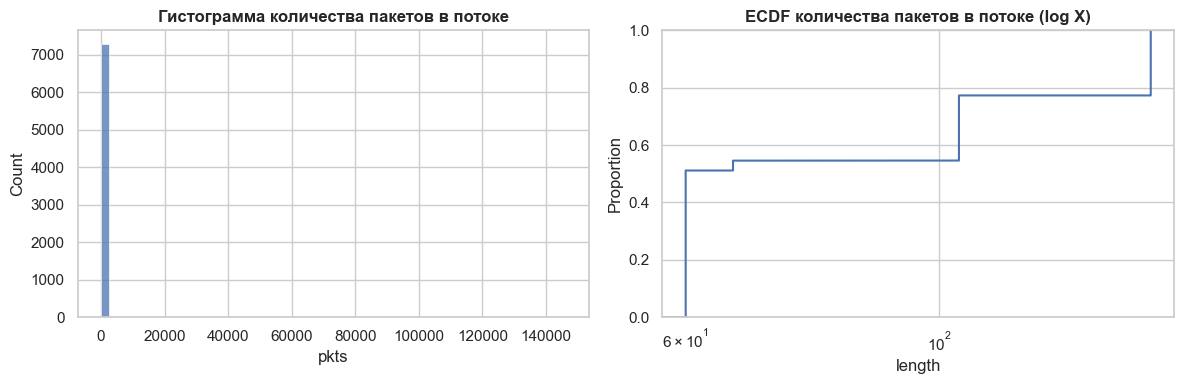

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(tcp['pkts'], bins=60, ax=axes[0], kde=False)
axes[0].set_title("Гистограмма количества пакетов в потоке")
sns.ecdfplot(length, ax=axes[1])
axes[1].set_xscale("log"); axes[1].set_title("ECDF количества пакетов в потоке (log X)")
plt.tight_layout(); plt.show()

In [42]:
tcp.sort_values("asym", ascending=False)

,flow_key,start,end,pkts,bytes_total,pkts_fwd,pkts_rev,bytes_fwd,bytes_rev,tcp_flags_set,src_ip,src_port,dst_ip,dst_port,l4,duration,class,asym
346,"(10.10.10.30, 51389, 10.10.10.10, 102, TCP)",1.445356e+09,1.445356e+09,1,60,1,0,60,0,{RA},10.10.10.30,51389,10.10.10.10,102,TCP,0.000000,rst_terminated,1.00
3487,"(10.10.10.30, 54530, 10.10.10.10, 102, TCP)",1.445359e+09,1.445359e+09,7,420,0,7,0,420,"{A, RA}",10.10.10.30,54530,10.10.10.10,102,TCP,5.997756,rst_terminated,1.00
3488,"(10.10.10.30, 54531, 10.10.10.10, 102, TCP)",1.445359e+09,1.445359e+09,7,420,0,7,0,420,"{A, RA}",10.10.10.30,54531,10.10.10.10,102,TCP,5.996394,rst_terminated,1.00
2646,"(10.10.10.30, 53689, 10.10.10.10, 102, TCP)",1.445358e+09,1.445358e+09,1,60,1,0,60,0,{RA},10.10.10.30,53689,10.10.10.10,102,TCP,0.000000,rst_terminated,1.00
2648,"(10.10.10.30, 53691, 10.10.10.10, 102, TCP)",1.445358e+09,1.445358e+09,8,480,1,7,60,420,"{A, RA}",10.10.10.30,53691,10.10.10.10,102,TCP,9.474959,rst_terminated,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,"(10.10.10.30, 50532, 10.10.10.10, 102, TCP)",1.445355e+09,1.445355e+09,2,120,1,1,60,60,{A},10.10.10.30,50532,10.10.10.10,102,TCP,0.000597,other,0.00
2,"(10.10.10.30, 50531, 10.10.10.10, 102, TCP)",1.445355e+09,1.445355e+09,2,120,1,1,60,60,{A},10.10.10.30,50531,10.10.10.10,102,TCP,0.000490,other,0.00
5,"(10.10.10.30, 50561, 10.10.10.10, 102, TCP)",1.445355e+09,1.445355e+09,2,120,1,1,60,60,{A},10.10.10.30,50561,10.10.10.10,102,TCP,0.000490,other,0.00
4,"(10.10.10.30, 50560, 10.10.10.10, 102, TCP)",1.445355e+09,1.445355e+09,2,120,1,1,60,60,{A},10.10.10.30,50560,10.10.10.10,102,TCP,0.000596,other,0.00


---
# Блок 4. Fumbling: обнаружение сканирования и ошибок конфигурации

> Атакующие перебирают разные варианты воздействия и порождают ошибки
> в сети или аномальные активности. Выделяем:
>
> - **горизонтальный скан** — один порт, много адресов;
> - **вертикальный скан** — один адрес, много портов;
> - **ICMP-ошибки** (Destination/Port Unreachable, Time Exceeded);
> - **DNS fumbling** — NXDOMAIN, длинные/энтропийные имена (DGA-кандидаты);
> - **HTTP fumbling** — массовые 4xx/5xx.

## Вычисления

Для каждого источника считаем *спред*: число уникальных адресов и портов
назначения, и долю потоков без ответа (classes `syn_only`, `syn_synack_no_ack`).

In [43]:
# Спред источника и доля неуспешных TCP-попыток
tcp_with_src = tcp.copy()
#неуспешные попытки - незавершенные рукопожатия + завершение сеанса по RST
tcp_with_src["failed"] = tcp_with_src["class"].isin(["syn_only","syn_synack_no_ack","rst_terminated"])

src_stats = tcp_with_src.groupby("src_ip").agg(
    flows = ("dst_ip","size"),
    uniq_dst_ip  = ("dst_ip","nunique"),
    uniq_dst_port= ("dst_port","nunique"),
    failed_rate  = ("failed","mean"),
).sort_values(["failed_rate","uniq_dst_ip"], ascending=False)




In [44]:
top_spread = src_stats[src_stats["flows"] >= 5]
top_spread



,flows,uniq_dst_ip,uniq_dst_port,failed_rate
src_ip,,,,
10.10.10.30,7291,1,1,0.990673


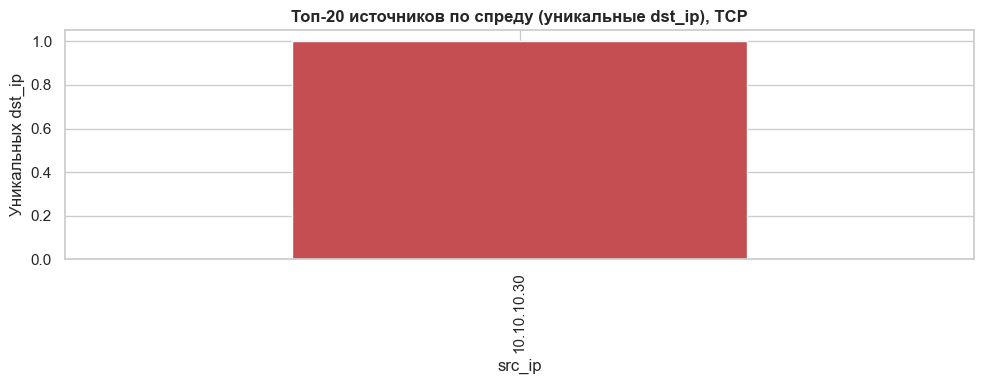

In [45]:
fig, ax = plt.subplots(figsize=(10,4))
top_spread["uniq_dst_ip"].plot.bar(ax=ax, color="#C44E52")
ax.set_title("Топ-20 источников по спреду (уникальные dst_ip), TCP")
ax.set_ylabel("Уникальных dst_ip")
plt.tight_layout(); plt.show()

In [46]:
# Горизонтальный vs вертикальный скан для каждого источника
# horizontal_ratio = uniq_dst_ip / flows; vertical_ratio = uniq_dst_port / flows
src_stats["horiz_ratio"] = src_stats["uniq_dst_ip"] / src_stats["flows"]
src_stats["vert_ratio"]  = src_stats["uniq_dst_port"]/ src_stats["flows"]

cand = src_stats[(src_stats["flows"] >= 10) & (src_stats["failed_rate"] > 0.5)]
print("Кандидаты на сканирование (failed_rate > 50%, >=10 потоков):")
display(cand.sort_values("horiz_ratio", ascending=False).head(15))


Кандидаты на сканирование (failed_rate > 50%, >=10 потоков):


,flows,uniq_dst_ip,uniq_dst_port,failed_rate,horiz_ratio,vert_ratio
src_ip,,,,,,
10.10.10.30,7291,1,1,0.990673,0.000137,0.000137


In [47]:
# ICMP-ошибки как индикатор fumbling
icmp = pkts[pkts["l4"] == "ICMP"].copy()
if len(icmp):
    icmp_summary = icmp.groupby(["icmp_type","icmp_code"]).size().reset_index(name="count")
    display(icmp_summary.sort_values("count", ascending=False).head(15))

    top_sources_icmp = icmp.groupby("src_ip").size().sort_values(ascending=False).head(10)
    print("\nИсточники ICMP-ошибок (топ-10):")
    display(top_sources_icmp)
else:
    print("ICMP в дампе отсутствует.")


,icmp_type,icmp_code,count
0,3.0,0.0,2735
1,11.0,0.0,5



Источники ICMP-ошибок (топ-10):


src_ip
192.168.89.1    2735
21.2.2.2           5
dtype: int64

In [49]:
# DNS fumbling: извлекаем запросы/ответы и смотрим NXDOMAIN, длину/энтропию имени
letterFrequency = {
    'E': 12.0, 'T': 9.10, 'A': 8.12, 'O': 7.68, 'I': 7.31, 'N': 6.95,
    'S': 6.28, 'R': 6.02, 'H': 5.92, 'D': 4.32, 'L': 3.98, 'U': 2.88,
    'C': 2.71, 'M': 2.61, 'F': 2.30, 'Y': 2.11, 'W': 2.09, 'G': 2.03,
    'P': 1.82, 'B': 1.49, 'V': 1.11, 'K': 0.69, 'X': 0.17, 'Q': 0.11,
    'J': 0.10, 'Z': 0.07,
}

# Нормируем проценты в вероятности и приводим ключи к нижнему регистру.
_TOTAL = sum(letterFrequency.values())
_REF_P = {k.lower(): v / _TOTAL for k, v in letterFrequency.items()}

# Малая вероятность для символов вне таблицы (цифры, дефис, точка, не-ASCII):
# без сглаживания -log2(0) сломает расчёт на первом же таком символе.
_SMOOTH = 1e-4

def shannon_entropy(s):
    """Кросс-энтропия строки под эталонным английским распределением букв,
    бит/символ.

    Для 'example.com' значение получится порядка 4 бит/символ,
    для DGA-подобного 'xkzqwvpj' — около 9+ бит/символ.
    Чем выше, тем меньше строка похожа на нормальный английский текст."""
    if not s:
        return 0.0
    chars = [c for c in s.lower() if c.isalpha()]
    if not chars:
        return 0.0
    return -sum(math.log2(_REF_P.get(c, _SMOOTH)) for c in chars) / len(chars)
    


In [50]:
%%time
dns_rows = []
with PcapReader(str(PCAP_PATH)) as rdr:
    for pkt in rdr:
        if pkt.haslayer(DNS):
            d = pkt[DNS]
            qname = ""
            try:
                if d.qd is not None:
                    qname = d.qd.qname.decode(errors="ignore").rstrip(".")
            except Exception:
                pass
            dns_rows.append({
                "ts": float(pkt.time),
                "qr": int(d.qr),          # 0=query, 1=response
                "rcode": int(d.rcode),    # 3 = NXDOMAIN
                "qname": qname,
                "qname_len": len(qname),
                "qname_entropy": shannon_entropy(qname),
            })
dns = pd.DataFrame(dns_rows)
print(f"DNS-сообщений: {len(dns):,}")
if len(dns):
    responses = dns[dns["qr"] == 1]
    if len(responses):
        nx_rate = (responses["rcode"] == 3).mean()
        print(f"Доля NXDOMAIN: {nx_rate:.1%}")
    dns["qname"].value_counts().head(10).to_frame("count")


DNS-сообщений: 30,277
Доля NXDOMAIN: 0.0%
CPU times: total: 34.9 s
Wall time: 35.1 s


In [51]:
dns.sort_values("qname_entropy", ascending=False)

,ts,qr,rcode,qname,qname_len,qname_entropy
14244,1.445366e+09,1,5,pmtsyzgjsqjoc,13,6.370445
14242,1.445366e+09,0,0,pmtsyzgjsqjoc,13,6.370445
1330,1.445355e+09,0,0,ooxvmbggoq,10,5.919885
1331,1.445355e+09,1,5,ooxvmbggoq,10,5.919885
5662,1.445359e+09,0,0,fyhrqwf,7,5.712716
...,...,...,...,...,...,...
53,1.445354e+09,0,0,localhost,9,4.117896
75,1.445354e+09,0,0,localhost,9,4.117896
74,1.445354e+09,0,0,localhost,9,4.117896
99,1.445354e+09,0,0,localhost,9,4.117896


---
# Блок 5. Объём, время, биконинг

> Временнóй анализ строится на трёх идеях:
>
> - **рабочий профиль** — сутки обычно имеют плато и провал; всплески в
>   «нерабочее» время подозрительны;
> - **биконинг** — канал управления (C2) периодичен, у него низкий CV
>   межинтервалов и пик автокорреляции на периоде T;
> - **локальность** — нормальный пользователь общается с небольшим
>   «рабочим множеством» хостов; резкий рост — признак raid/эксфильтрации.

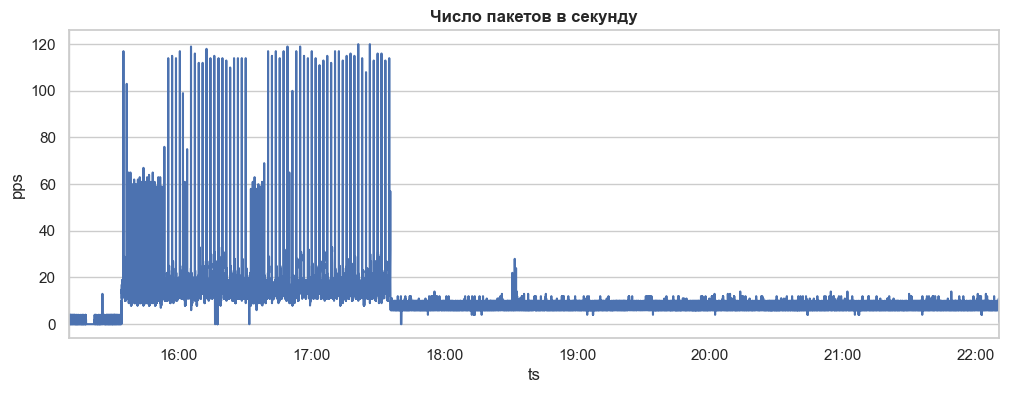

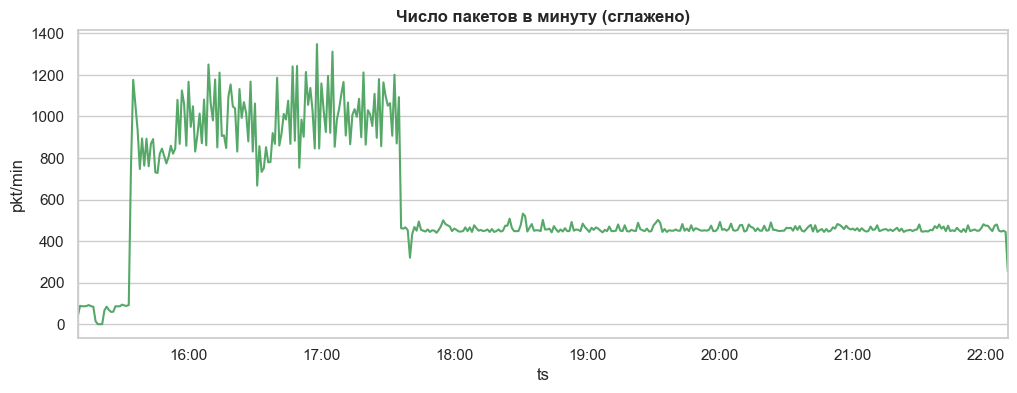

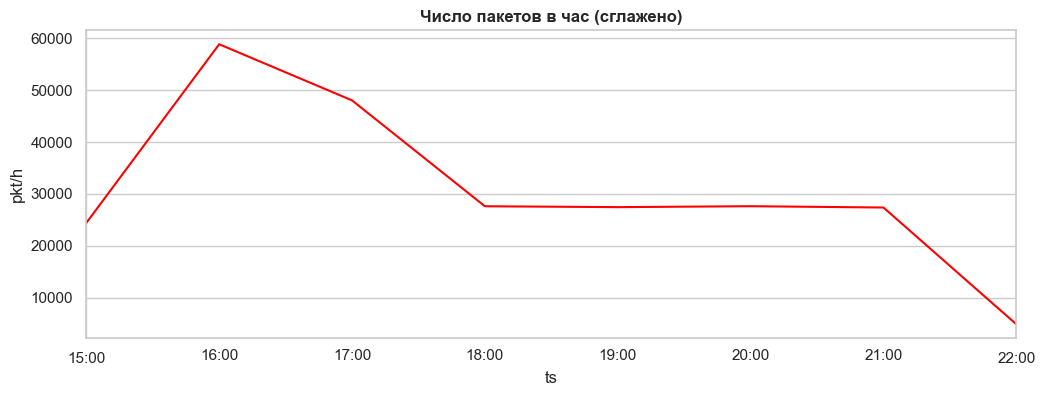

In [54]:
ts_series = pd.Series(1, index=pd.to_datetime(pkts["ts"], unit="s", utc=True))
by_sec = ts_series.resample("1s").sum()

fig, ax = plt.subplots(figsize=(12, 4))
by_sec.plot(ax=ax, color="#4C72B0")
ax.set_title("Число пакетов в секунду")
ax.set_ylabel("pps")
plt.show()

by_min = ts_series.resample("1min").sum()
fig, ax = plt.subplots(figsize=(12, 4))
by_min.plot(ax=ax, color="#55A868")
ax.set_title("Число пакетов в минуту (сглажено)")
ax.set_ylabel("pkt/min")
plt.show()

by_hour = ts_series.resample("1h").sum()
fig, ax = plt.subplots(figsize=(12, 4))
by_hour.plot(ax=ax, color="red")
ax.set_title("Число пакетов в час (сглажено)")
ax.set_ylabel("pkt/h")
plt.show()


In [55]:
# Локальность: окно уникальных dst_ip по каждому src_ip
p = pkts.dropna(subset=["src_ip","dst_ip"]).copy()
p["dt"] = pd.to_datetime(p["ts"], unit="s", utc=True)




In [56]:
flows.groupby('src_ip')['dst_ip'].nunique().sort_values(ascending=False)

src_ip
192.168.89.2     3
192.168.88.52    2
10.10.10.30      1
10.10.10.20      1
192.168.88.61    1
21.2.2.2         1
Name: dst_ip, dtype: int64

In [57]:
top_src='192.168.89.2'

In [58]:
sub = p[p["src_ip"] == top_src].set_index("dt").sort_index()

In [59]:
# Количество уникальных dst_ip в  окне 5 минут
uniq_rolling = (sub["dst_ip"].resample("5min").nunique())

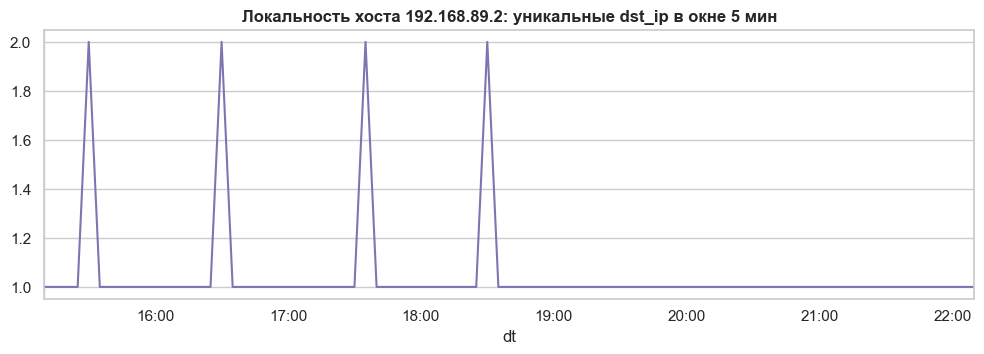

In [60]:
fig, ax = plt.subplots(figsize=(12,3.5))
uniq_rolling.plot(ax=ax, color="#8172B2")
ax.set_title(f"Локальность хоста {top_src}: уникальные dst_ip в окне 5 мин")
plt.show()


---
# Блок 6. Контент-анализ, идентификация приложений, граф коммуникаций

> Текст в трафике (DNS, HTTP, TLS SNI) —
> источник быстрых и надёжных выводов о приложении. Граф коммуникаций
> (NetworkX) показывает «центральные» узлы — хабы, серверы, маршрутизаторы.

## План блока

1. HTTP: Host, URI, User-Agent, коды ответа (сканируем Raw-слой на ASCII-заголовки).
2. TLS SNI: вытащить из ClientHello, без расшифровки.
3. Идентификация приложения: порт vs баннер vs поведение — сравнение.
4. Граф: NetworkX.DiGraph по потокам, центральности degree/betweenness/closeness.

In [61]:
# Простой извлекатель HTTP-заголовков из Raw-слоя
import re
RE_HTTP_REQ  = re.compile(rb"^(?P<method>GET|POST|PUT|DELETE|HEAD|OPTIONS|PATCH)\s+(?P<uri>\S+)\s+HTTP/1\.[01]", re.M)
RE_HTTP_HDR  = re.compile(rb"^(?P<name>[A-Za-z\-]+):\s*(?P<val>[^\r\n]+)", re.M)
RE_HTTP_RESP = re.compile(rb"^HTTP/1\.[01]\s+(?P<code>\d{3})", re.M)

In [62]:
PCAP_PATH = Path("http_espn_fail.pcapng")
assert PCAP_PATH.exists(), f"pcap не найден: {PCAP_PATH}"
http_rows = []
with PcapReader(str(PCAP_PATH)) as rdr:
    for pkt in rdr:
        if pkt.haslayer(Raw) and pkt.haslayer(TCP):
            raw = bytes(pkt[Raw].load)[:2000]
            if b"HTTP/1." not in raw:
                continue
            row = {"ts": float(pkt.time),
                   "src_ip": pkt[IP].src if pkt.haslayer(IP) else None,
                   "dst_ip": pkt[IP].dst if pkt.haslayer(IP) else None,
                   "dst_port": int(pkt[TCP].dport),
                   "method": None, "uri": None, "host": None,
                   "user_agent": None, "code": None}
            m = RE_HTTP_REQ.search(raw)
            if m:
                row["method"] = m.group("method").decode()
                row["uri"]    = m.group("uri").decode(errors="ignore")
            m = RE_HTTP_RESP.search(raw)
            if m:
                row["code"] = int(m.group("code"))
            for hm in RE_HTTP_HDR.finditer(raw):
                name = hm.group("name").decode().lower()
                val  = hm.group("val").decode(errors="ignore")
                if name == "host":        row["host"] = val
                elif name == "user-agent":row["user_agent"] = val
            http_rows.append(row)

http = pd.DataFrame(http_rows)
print(f"HTTP-наблюдений: {len(http):,}")

HTTP-наблюдений: 14


In [63]:
http['code'].value_counts()

code
200.0    6
301.0    1
Name: count, dtype: int64

In [64]:
http['method'].value_counts()

method
GET    7
Name: count, dtype: int64

In [65]:
# TLS SNI: выделяем ClientHello без scapy-tls, прямо из сырого TCP payload (443/tcp)
def extract_sni(pkt):
    """
    Возвращает строку SNI, если пакет содержит TLS ClientHello
    с расширением server_name, иначе None.
    """
    if not pkt.haslayer(TLSClientHello):
        return None
    ch = pkt[TLSClientHello]
    # ch.ext — список расширений; в зависимости от версии scapy
    # может быть None, поэтому подстраховываемся.
    for ext in getattr(ch, "ext", None) or []:
        if isinstance(ext, TLS_Ext_ServerName):
            for srv in getattr(ext, "servernames", None) or []:
                name = getattr(srv, "servername", b"")
                if isinstance(name, (bytes, bytearray)):
                    try:
                        return name.decode("idna")
                    except Exception:
                        return name.decode("utf-8", errors="ignore")
                return str(name)
    return None

In [66]:
PCAP_PATH= Path("tls.pcapng")
assert PCAP_PATH.exists(), f"pcap не найден: {PCAP_PATH}"

In [67]:
load_layer("tls")
sni_rows = []
with PcapReader(str(PCAP_PATH)) as reader:
    for pkt in reader:
        # Быстрый фильтр: только TCP и только порт 443 с одной из сторон.
        if not pkt.haslayer(TCP):
            continue
        tcp = pkt[TCP]
        if tcp.dport != 443 and tcp.sport != 443:
            continue

        sni = extract_sni(pkt)
        if sni is None:
            continue

        if pkt.haslayer(IP):
            src, dst = pkt[IP].src, pkt[IP].dst
        elif pkt.haslayer(IPv6):
            src, dst = pkt[IPv6].src, pkt[IPv6].dst
        else:
            continue

        sni_rows.append({
            "ts":   float(pkt.time),
            "src":  src,
            "dst":  dst,
            "sport": int(tcp.sport),
            "dport": int(tcp.dport),
            "sni":  sni,
        })

sni = pd.DataFrame(sni_rows)
print(f"SNI-наблюдений: {len(sni):,}")

SNI-наблюдений: 1


In [68]:
sni

,ts,src,dst,sport,dport,sni
0,1.773185e+09,192.168.2.79,2.17.146.65,58699,443,assets.msn.com


In [69]:
# Граф коммуникаций: узлы — IP, рёбра — потоки (вес = байты)
G = nx.DiGraph()
for _, row in flows.iterrows():
    src = f"{row['src_ip']}:{row['src_port']}"
    dst = f"{row['dst_ip']}:{row['dst_port']}"
    w = int(row["bytes_total"])
    if G.has_edge(row["src_ip"], row["dst_ip"]):
        G[row["src_ip"]][row["dst_ip"]]["weight"] += w
        G[row["src_ip"]][row["dst_ip"]]["flows"]  += 1
    else:
        G.add_edge(row["src_ip"], row["dst_ip"], weight=w, flows=1)

print(f"Узлов: {G.number_of_nodes():,}; Рёбер: {G.number_of_edges():,}")

# Центральности
deg   = pd.Series(dict(G.degree(weight="flows")), name="degree_flows")
#Степень посредничества (betweeness) для каждой вершины равна числу этих кратчайших путей через вершину
btw   = pd.Series(nx.betweenness_centrality(G, k=min(200, G.number_of_nodes()),
                                            weight="flows", seed=1), name="betweenness")
central = pd.concat([deg, btw], axis=1).sort_values("betweenness", ascending=False)
display(central.head(10))


Узлов: 12; Рёбер: 9


,degree_flows,betweenness
192.168.88.52,80,0.018182
10.10.10.20,1,0.000000
10.10.10.10,7292,0.000000
10.10.10.30,7291,0.000000
192.168.88.1,79,0.000000
192.195.142.13,1,0.000000
192.168.88.61,1,0.000000
192.168.89.2,2446,0.000000
192.168.89.1,1,0.000000
17.253.34.253,1,0.000000


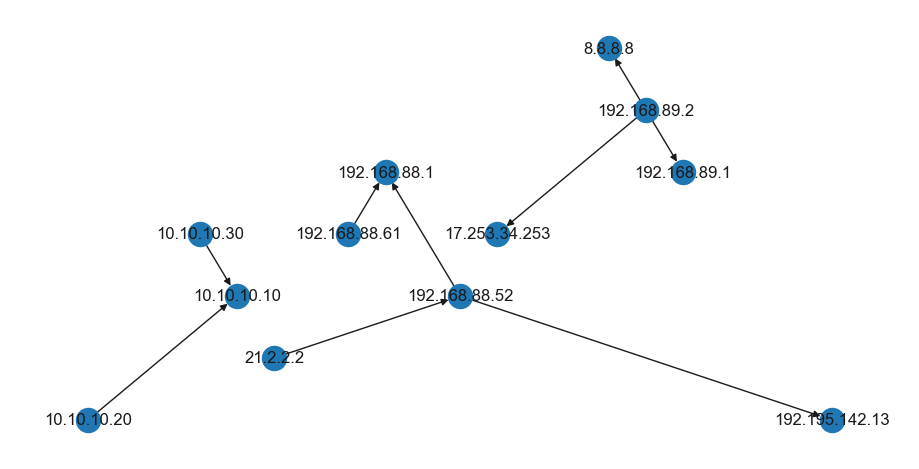

In [70]:
# Визуализация «ядра» графа: подграф на 30 самых центральных узлах
top_nodes = central.head(30).index.tolist()
H = G.subgraph(top_nodes)
pos = nx.planar_layout(H)
nx.draw(H, pos, with_labels=True)